# 06 — Modelado completo y búsqueda de hiperparámetros

Notebook de modelado y búsqueda de hiperparámetros sobre `features_baseline.parquet`.

**Reglas obligatorias**

- Target: `rhythm_label` (clasificación multiclase de arritmias intraoperatorias).
- `case_id` se usa como grupo para split y CV — sin leakage entre pacientes.
- `beat_type` está prohibido como predictor (bloqueado por `assert_no_forbidden_features`).
- Split 80/20 por `case_id` con cobertura de clases (`make_train_test_group_split_with_coverage`).
- CV interna por grupo (`StratifiedGroupKFold` cuando es viable; `GroupKFold` como fallback).
- El test se evalúa **una sola vez** al final, después de fijar hiperparámetros con CV en train.
- Métrica primaria: `f1_macro`. Complementarias: `precision_macro`, `recall_macro`, `accuracy`.

**Modelos comparados**

SVM (`LinearSVC`), Árbol de Decisión, Random Forest, XGBoost, MLP.

**Pre-requisito**

Haber ejecutado `04_windowing_and_feature_engineering.ipynb` para generar `data/processed/features_baseline.parquet`.

## 1. Setup

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src import config
from src.evaluation import confusion_matrix_with_totals, per_class_report
from src.modeling import (
    assert_no_forbidden_features,
    make_train_test_group_split_with_coverage,
)
from src.search import (
    MODEL_REGISTRY,
    PRIMARY_SCORING,
    build_cv_splitter,
    evaluate_on_test,
    run_search_for_model,
)
from src.utils import get_logger, set_seed

set_seed(config.RANDOM_SEED)
logger = get_logger("nb06")
sns.set_theme(context="notebook", style="whitegrid")

In [ ]:

# ── Diagnóstico de dispositivos de entrenamiento ──────────────────────────────
import subprocess as _sp

def _check_cuda():
    try:
        r = _sp.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5,
        )
        if r.returncode == 0:
            name = r.stdout.strip().split("\n")[0]
            if name:
                return True, name
    except Exception:
        pass
    return False, ""

_cuda_ok, _gpu_name = _check_cuda()
_xgb_device = f"GPU  {_gpu_name}  [CUDA]" if _cuda_ok else "CPU  (CUDA no detectada)"

print("=" * 56)
print("  DISPOSITIVOS DE ENTRENAMIENTO")
print("=" * 56)
print(f"  linear_svc    →  CPU  (sklearn, sin GPU multiclase)")
print(f"  decision_tree →  CPU  (sklearn)")
print(f"  random_forest →  CPU  (sklearn)")
print(f"  xgboost       →  {_xgb_device}")
print(f"  mlp           →  CPU  (sklearn)")
print("=" * 56)
if not _cuda_ok:
    print("  AVISO: GPU no detectada — XGBoost también usará CPU.")
else:
    print("  XGBoost usará GPU automáticamente en el entrenamiento.")
print("  Para RF/DT/MLP en GPU: ver notebook 06b_gpu_modeling.ipynb")
print("=" * 56)


## 2. Configuración del run

Ajusta `FAST_MODE` según el alcance:
- `FAST_MODE = True`  → rápido (N_ITER=5, N_SPLITS=3) — útil para depurar.
- `FAST_MODE = False` → completo (N_ITER=30, N_SPLITS=5) — resultados finales.

In [ ]:
FAST_MODE = False  # True para pruebas rápidas, False para corrida final

N_ITER   = 5  if FAST_MODE else 30
N_SPLITS = 3  if FAST_MODE else 5
TEST_SIZE = 0.2
N_JOBS   = -1

# Modelos comprometidos en el proyecto
MODELS_TO_RUN = ["linear_svc", "decision_tree", "random_forest", "xgboost", "mlp"]

# Si no está vacía, solo se entrenan esos modelos (útil para re-correr uno que falló).
# Ejemplo: FORCE_RERUN_MODELS = ["xgboost"]
FORCE_RERUN_MODELS = []

_models_effective = FORCE_RERUN_MODELS if FORCE_RERUN_MODELS else MODELS_TO_RUN

if FAST_MODE:
    print("AVISO: FAST_MODE=True — corrida rápida de prueba (N_ITER=5). "
          "Para resultados finales usa FAST_MODE=False (N_ITER=30).")
print(f"FAST_MODE          : {FAST_MODE}")
print(f"N_ITER             : {N_ITER}")
print(f"N_SPLITS           : {N_SPLITS}")
print(f"TEST_SIZE          : {TEST_SIZE}")
print(f"MODELS_TO_RUN      : {MODELS_TO_RUN}")
print(f"FORCE_RERUN_MODELS : {FORCE_RERUN_MODELS}")
print(f"Modelos a entrenar : {_models_effective}")

AVISO: FAST_MODE=True — corrida rápida de prueba (N_ITER=5). Para resultados finales usa FAST_MODE=False (N_ITER=30).
FAST_MODE          : True
N_ITER             : 5
N_SPLITS           : 3
TEST_SIZE          : 0.2
MODELS_TO_RUN      : ['linear_svc', 'decision_tree', 'random_forest', 'xgboost', 'mlp']
FORCE_RERUN_MODELS : []
Modelos a entrenar : ['linear_svc', 'decision_tree', 'random_forest', 'xgboost', 'mlp']


## 3. Diagnóstico inicial

Se imprime antes de entrenar para detectar problemas de carga, leakage o features incorrectas.

In [4]:
features_parquet = config.PROCESSED_DIR / "features_baseline.parquet"
features_csv     = config.PROCESSED_DIR / "features_baseline.csv"

print("=" * 70)
print("DIAGNÓSTICO INICIAL")
print("=" * 70)
print(f"Ruta parquet  : {features_parquet}")
print(f"Existe parquet: {features_parquet.exists()}")
print(f"Ruta CSV      : {features_csv}")
print(f"Existe CSV    : {features_csv.exists()}")
print("=" * 70)

DIAGNÓSTICO INICIAL
Ruta parquet  : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed\features_baseline.parquet
Existe parquet: True
Ruta CSV      : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\data\processed\features_baseline.csv
Existe CSV    : False


## 4. Carga robusta de datos

Intenta cargar `features_baseline.parquet`; si falla (pyarrow ausente, archivo corrupto), usa el CSV como fallback.

In [5]:
try:
    df_raw = pd.read_parquet(features_parquet)
    load_source = f"parquet ({features_parquet.name})"
except Exception as e_parquet:
    print(f"[AVISO] No se pudo leer parquet: {e_parquet}")
    print(f"Intentando CSV: {features_csv}")
    df_raw = pd.read_csv(features_csv)
    load_source = f"CSV ({features_csv.name})"

# Limpiar filas con label inválido (NaN real o string 'nan')
n_raw = len(df_raw)
df = df_raw.dropna(subset=[config.TARGET_COLUMN])
mask_string_nan = (
    df[config.TARGET_COLUMN]
    .astype(str).str.strip().str.lower()
    .isin({"nan", "none", ""})
)
df = df.loc[~mask_string_nan].copy()
n_clean = len(df)

print(f"Fuente          : {load_source}")
print(f"Filas cargadas  : {n_raw:,}  |  Con label válido: {n_clean:,}")
print(f"Shape           : {df.shape}")
print(f"\nColumnas ({len(df.columns)}):")
print(list(df.columns))
print(f"\nConteo de {config.TARGET_COLUMN}:")
print(df[config.TARGET_COLUMN].value_counts().sort_index())
print(f"\ncase_id únicos: {df[config.CASE_ID_COLUMN].nunique()}")

Fuente          : parquet (features_baseline.parquet)
Filas cargadas  : 638,690  |  Con label válido: 638,690
Shape           : (638690, 39)

Columnas (39):
['case_id', 'window_id', 'beat_index', 'start_sample', 'end_sample', 'start_time', 'end_time', 'rhythm_label', 'original_nan_pct', 'max_nan_gap_seconds', 'was_interpolated', 'quality_status', 'quality_reason', 'mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']

Conteo de rhythm_label:
rhythm_label
AFIB/AFL                        158473
AVB                               4193
N                               391877
Patterned Atrial Ectopy          19946
Patterned Ventricular Ectopy     23902
SND                              22224
SVTA                              6396
Unclassifiable     

## 5. Selección segura de features

Reutiliza la lógica del notebook 05: excluye metadatos, columnas de auditoría de calidad y cualquier
columna prohibida por `config.FORBIDDEN_FEATURE_COLUMNS`. Luego selecciona únicamente columnas numéricas.
Se verifica que `rhythm_label`, `case_id` y `beat_type` no entren como predictores.

In [6]:
# Columnas a excluir explícitamente (además de FORBIDDEN_FEATURE_COLUMNS)
EXTRA_NON_FEATURES = {
    "beat_index", "start_sample", "end_sample",
    "window_id",  "start_time",  "end_time",
    "quality_status", "quality_reason",
    "original_nan_pct", "max_nan_gap_seconds", "was_interpolated",
    "window_seconds",
    config.BEAT_TIME_COLUMN,
}
non_feature_set = set(config.FORBIDDEN_FEATURE_COLUMNS) | EXTRA_NON_FEATURES

# Candidatas → solo numéricas
candidate_cols = [c for c in df.columns if c not in non_feature_set]
feature_cols = (
    df[candidate_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# Validaciones metodológicas (deben pasar sin AssertionError)
assert_no_forbidden_features(feature_cols)
assert config.TARGET_COLUMN not in feature_cols, "rhythm_label no debe ser feature"
assert config.CASE_ID_COLUMN not in feature_cols, "case_id no debe ser feature"
assert "beat_type" not in feature_cols, "beat_type no debe ser feature"
assert len(feature_cols) > 0, "No quedaron columnas numéricas válidas"

X      = df[feature_cols].to_numpy(dtype=float)
y      = df[config.TARGET_COLUMN].to_numpy()
groups = df[config.CASE_ID_COLUMN].to_numpy()

print(f"Features seleccionadas ({len(feature_cols)}):")
print(feature_cols)
print(f"\nX shape  : {X.shape}")
print(f"y shape  : {y.shape}")
print(f"NaN en X : {int(np.isnan(X).sum())}  (serán imputados dentro del Pipeline)")
print(f"\nGrupos únicos : {np.unique(groups).shape[0]}")
print(f"Clases únicas : {np.unique(y).tolist()}")

Features seleccionadas (26):
['mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']

X shape  : (638690, 26)
y shape  : (638690,)
NaN en X : 1920  (serán imputados dentro del Pipeline)

Grupos únicos : 481
Clases únicas : ['AFIB/AFL', 'AVB', 'N', 'Patterned Atrial Ectopy', 'Patterned Ventricular Ectopy', 'SND', 'SVTA', 'Unclassifiable', 'VT', 'WAP/MAT']


## 6. Split por `case_id` — sin leakage entre pacientes

`make_train_test_group_split_with_coverage` garantiza que todas las clases estén
representadas en train. Se verifica explícitamente que no haya grupos en común entre
train y test.

In [7]:
train_idx, test_idx, split_info = make_train_test_group_split_with_coverage(
    X, y, groups,
    test_size=TEST_SIZE,
    random_state=config.RANDOM_SEED,
)

X_train, X_test           = X[train_idx],      X[test_idx]
y_train, y_test           = y[train_idx],      y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Validación estricta: ningún case_id puede estar en ambos conjuntos
train_groups_set = set(groups_train.tolist())
test_groups_set  = set(groups_test.tolist())
overlap = train_groups_set & test_groups_set
assert len(overlap) == 0, f"Leakage detectado: grupos en ambos lados = {overlap}"

print("Validación de leakage: OK (0 grupos en común entre train y test)")
print(f"Grupos en train : {len(train_groups_set)}")
print(f"Grupos en test  : {len(test_groups_set)}")
print(f"Ventanas train  : {len(train_idx):,}")
print(f"Ventanas test   : {len(test_idx):,}")
print(f"\nSplit info: {split_info}")
print(f"\nDistribución de clases en TRAIN:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nDistribución de clases en TEST:")
print(pd.Series(y_test).value_counts().sort_index())

Validación de leakage: OK (0 grupos en común entre train y test)
Grupos en train : 384
Grupos en test  : 97
Ventanas train  : 509,707
Ventanas test   : 128,983

Split info: {'chosen_seed': 43, 'n_classes_covered': 10, 'n_total_classes': 10, 'attempts_tried': 2, 'actual_test_fraction': 0.2019493024785107, 'requested_test_size': 0.2, 'train_groups': [1001, 1018, 1023, 103, 1063, 1072, 1083, 1086, 110, 1110, 1115, 1121, 1127, 114, 1157, 1165, 1191, 12, 1207, 1269, 1276, 1292, 1293, 13, 1314, 1317, 1350, 1367, 1375, 1378, 1398, 1404, 1407, 1415, 146, 1484, 1488, 1523, 158, 1590, 1605, 1607, 1622, 1623, 1626, 1628, 1632, 166, 1665, 1699, 1714, 1730, 1733, 1776, 178, 1798, 1800, 1827, 1828, 1840, 19, 1901, 1903, 1914, 1915, 1957, 1959, 1994, 2008, 2016, 2042, 2054, 2058, 2071, 208, 2103, 2149, 2158, 2161, 2191, 2212, 2213, 2221, 2231, 2246, 2252, 2283, 2296, 230, 2305, 2345, 2348, 2349, 2381, 2397, 2399, 2400, 2424, 2428, 2432, 2447, 2453, 2489, 2495, 2505, 251, 2556, 2558, 257, 2585, 2588, 

## 7. CV splitter interno

Usa `StratifiedGroupKFold` si es viable (sklearn ≥ 1.0); cae a `GroupKFold` si no.
El número de folds se recorta al número de grupos en train cuando sea necesario.

In [8]:
cv, cv_name, n_splits_eff = build_cv_splitter(
    groups_train=groups_train,
    y_train=y_train,
    n_splits=N_SPLITS,
    prefer_stratified=True,
)
print(f"CV splitter     : {cv_name}")
print(f"n_splits efectivo: {n_splits_eff}")

CV splitter     : StratifiedGroupKFold
n_splits efectivo: 3


## 8. Entrenamiento con `RandomizedSearchCV` — un modelo a la vez

Cada modelo se envuelve en `try/except`. Si falla (XGBoost no instalado, memoria insuficiente,
etc.), se registra `status='error'` con el mensaje de error y el resto de modelos continúa.
El test **no se toca** durante la búsqueda: solo se evalúa una vez al final.

> **Nota**: Con `FAST_MODE=True` el entrenamiento tarda ~2-10 min según hardware.
> Para resultados finales, poner `FAST_MODE=False` y re-ejecutar.

In [9]:
model_rows = []

for model_name in _models_effective:

    if model_name not in MODEL_REGISTRY:
        model_rows.append({
            "model": model_name,
            "status": "unknown",
            "error_message": f"Modelo {model_name!r} no está en MODEL_REGISTRY",
        })
        print(f"[{model_name}] status=unknown — no está en MODEL_REGISTRY")
        continue

    spec = MODEL_REGISTRY[model_name]
    logger.info("=== Entrenando: %s ===", model_name)

    try:
        if model_name == "xgboost":
            try:
                import xgboost  # noqa: F401
            except ImportError as ie:
                raise ImportError(
                    "xgboost no está instalado. Ejecutar: pip install xgboost"
                ) from ie

        res  = run_search_for_model(
            spec=spec,
            X_train=X_train,
            y_train=y_train,
            groups_train=groups_train,
            cv=cv,
            n_iter=N_ITER,
            random_state=config.RANDOM_SEED,
            n_jobs=N_JOBS,
        )
        test = evaluate_on_test(res, X_test, y_test)

        row = {
            "model":                model_name,
            "status":               "ok",
            "n_features":           int(X_train.shape[1]),
            "train_size":           int(len(train_idx)),
            "test_size":            int(len(test_idx)),
            "n_train_groups":       len(train_groups_set),
            "n_test_groups":        len(test_groups_set),
            "best_params":          json.dumps(res["best_params"], default=str),
            "fit_time_seconds":     round(res["fit_seconds"], 2),
            "cv_f1_macro":          res["cv_metrics"].get("cv_f1_macro", float("nan")),
            "test_accuracy":        test.get("test_accuracy",        float("nan")),
            "test_precision_macro": test.get("test_precision_macro", float("nan")),
            "test_recall_macro":    test.get("test_recall_macro",    float("nan")),
            "test_f1_macro":        test.get("test_f1_macro",        float("nan")),
            "test_f1_weighted":     test.get("test_f1_weighted",     float("nan")),
            "error_message":        "",
            # Objetos Python — excluidos del CSV pero usados en celdas siguientes
            "_best_estimator":      res["best_estimator"],
            "_y_pred_test":         test["y_pred"],
        }
        logger.info("  %s OK: test_f1_macro=%.4f", model_name, row["test_f1_macro"])

    except Exception as exc:
        logger.error("  %s FALLÓ: %s", model_name, exc)
        row = {
            "model":                model_name,
            "status":               "error",
            "n_features":           int(X_train.shape[1]),
            "train_size":           int(len(train_idx)),
            "test_size":            int(len(test_idx)),
            "n_train_groups":       len(train_groups_set),
            "n_test_groups":        len(test_groups_set),
            "best_params":          "{}",
            "fit_time_seconds":     float("nan"),
            "cv_f1_macro":          float("nan"),
            "test_accuracy":        float("nan"),
            "test_precision_macro": float("nan"),
            "test_recall_macro":    float("nan"),
            "test_f1_macro":        float("nan"),
            "test_f1_weighted":     float("nan"),
            "error_message":        f"{type(exc).__name__}: {exc}",
            "_best_estimator":      None,
            "_y_pred_test":         None,
        }

    model_rows.append(row)
    status_str = row["status"]
    extra = (
        f"test_f1_macro={row['test_f1_macro']:.4f}  fit={row['fit_time_seconds']}s"
        if status_str == "ok"
        else row["error_message"][:120]
    )
    print(f"[{model_name}] status={status_str}  {extra}")

2026-05-21 13:59:33 | nb06 | INFO | === Entrenando: linear_svc ===
2026-05-21 14:02:40 | nb06 | INFO |   linear_svc OK: test_f1_macro=0.3439
2026-05-21 14:02:40 | nb06 | INFO | === Entrenando: decision_tree ===


[linear_svc] status=ok  test_f1_macro=0.3439  fit=185.44s


2026-05-21 14:03:20 | nb06 | INFO |   decision_tree OK: test_f1_macro=0.2332
2026-05-21 14:03:20 | nb06 | INFO | === Entrenando: random_forest ===


[decision_tree] status=ok  test_f1_macro=0.2332  fit=38.51s


2026-05-21 14:27:48 | nb06 | INFO |   random_forest OK: test_f1_macro=0.3225
2026-05-21 14:27:48 | nb06 | INFO | === Entrenando: xgboost ===


[random_forest] status=ok  test_f1_macro=0.3225  fit=1466.6s


2026-05-21 14:38:30 | nb06 | INFO |   xgboost OK: test_f1_macro=0.2739
2026-05-21 14:38:30 | nb06 | INFO | === Entrenando: mlp ===


[xgboost] status=ok  test_f1_macro=0.2739  fit=640.04s


2026-05-21 14:47:52 | nb06 | INFO |   mlp OK: test_f1_macro=0.3065


[mlp] status=ok  test_f1_macro=0.3065  fit=560.95s


## 9. Construcción de `comparison_df`

Se construye explícitamente con columna `status` garantizada. Las columnas `_best_estimator`
y `_y_pred_test` (objetos Python, no serializables) se excluyen del DataFrame para no romper
el guardado a CSV pero se mantienen en `model_rows` para las secciones siguientes.

In [10]:
# Columnas que van al DataFrame (excluye claves internas con prefijo '_')
REPORT_COLS = [
    "model", "status", "n_features", "train_size", "test_size",
    "n_train_groups", "n_test_groups", "best_params", "fit_time_seconds",
    "cv_f1_macro", "test_accuracy", "test_precision_macro",
    "test_recall_macro", "test_f1_macro", "test_f1_weighted", "error_message",
]

comparison_df = pd.DataFrame([
    {c: row.get(c, float("nan")) for c in REPORT_COLS}
    for row in model_rows
])

print(f"comparison_df shape : {comparison_df.shape}")
print(f"Columnas: {comparison_df.columns.tolist()}")
print()
cols_show = ["model", "status", "test_f1_macro", "test_precision_macro",
             "test_recall_macro", "test_accuracy"]
cols_show = [c for c in cols_show if c in comparison_df.columns]
print(comparison_df[cols_show].round(4).to_string(index=False))

comparison_df shape : (5, 16)
Columnas: ['model', 'status', 'n_features', 'train_size', 'test_size', 'n_train_groups', 'n_test_groups', 'best_params', 'fit_time_seconds', 'cv_f1_macro', 'test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro', 'test_f1_weighted', 'error_message']

        model status  test_f1_macro  test_precision_macro  test_recall_macro  test_accuracy
   linear_svc     ok         0.3439                0.4093             0.3515         0.8061
decision_tree     ok         0.2332                0.2326             0.2938         0.7220
random_forest     ok         0.3225                0.2952             0.4248         0.7879
      xgboost     ok         0.2739                0.3052             0.2710         0.8203
          mlp     ok         0.3065                0.3685             0.2932         0.8204


## 10. Comparación de modelos

Celda defensiva: verifica si `comparison_df` está vacío, si existe `status`, y si existe la
métrica primaria. Como `features_baseline` corresponde a una sola configuración de ventana,
no se pivota por `window_seconds`; se muestra una tabla simple ordenada por `test_f1_macro`.

In [11]:
PRIMARY_METRIC = f"test_{PRIMARY_SCORING}"  # 'test_f1_macro'

if comparison_df.empty:
    print("AVISO: comparison_df está vacío. No hay resultados que mostrar.")

elif "status" not in comparison_df.columns:
    print("AVISO: comparison_df no tiene columna 'status'.")
    print("Columnas disponibles:", comparison_df.columns.tolist())

else:
    ok = comparison_df.loc[comparison_df["status"] == "ok"].copy()

    if ok.empty:
        print("AVISO: Ningún modelo completó con status='ok'. Tabla de errores:")
        display(comparison_df[["model", "status", "error_message"]])

    else:
        # Resolver métrica primaria a mostrar
        if PRIMARY_METRIC not in ok.columns:
            PRIMARY_METRIC = "test_f1_macro"
            print(f"[AVISO] Usando '{PRIMARY_METRIC}' como métrica principal.")

        # Una sola ventana → tabla simple (no pivotear por window_seconds)
        display_cols = [
            "model", "test_f1_macro", "test_precision_macro",
            "test_recall_macro", "test_accuracy",
            "cv_f1_macro", "fit_time_seconds",
        ]
        display_cols = [c for c in display_cols if c in ok.columns]

        print(f"Comparación de modelos — ordenada por {PRIMARY_METRIC}:\n")
        display(
            ok[display_cols]
            .sort_values(PRIMARY_METRIC, ascending=False)
            .reset_index(drop=True)
            .round(4)
        )

        # Mostrar modelos con error si los hay
        err = comparison_df.loc[comparison_df["status"] != "ok"]
        if not err.empty:
            print("\nModelos que fallaron:")
            display(err[["model", "status", "error_message"]])

Comparación de modelos — ordenada por test_f1_macro:



,model,test_f1_macro,test_precision_macro,test_recall_macro,test_accuracy,cv_f1_macro,fit_time_seconds
0,linear_svc,0.3439,0.4093,0.3515,0.8061,0.2954,185.44
1,random_forest,0.3225,0.2952,0.4248,0.7879,0.2880,1466.60
2,mlp,0.3065,0.3685,0.2932,0.8204,0.2833,560.95
3,xgboost,0.2739,0.3052,0.2710,0.8203,0.3349,640.04
4,decision_tree,0.2332,0.2326,0.2938,0.7220,0.2311,38.51


## 11. Mejor modelo global

Se selecciona el modelo con mayor `test_f1_macro`. Se reporta el classification report
completo y la tabla por clase con soporte.

In [12]:
ok_rows = [
    r for r in model_rows
    if r.get("status") == "ok" and r.get("_y_pred_test") is not None
]

if not ok_rows:
    print("Sin ganadores válidos (status='ok'). Revisa los errores en la tabla anterior.")
    winner_row    = None
    winner_name   = None
    y_pred_winner = None

else:
    winner_row    = max(ok_rows, key=lambda r: r.get("test_f1_macro", -1.0))
    winner_name   = winner_row["model"]
    y_pred_winner = winner_row["_y_pred_test"]

    print("=" * 60)
    print(f"MEJOR MODELO: {winner_name}")
    print("=" * 60)
    print(f"  test_f1_macro        : {winner_row['test_f1_macro']:.4f}")
    print(f"  test_precision_macro : {winner_row['test_precision_macro']:.4f}")
    print(f"  test_recall_macro    : {winner_row['test_recall_macro']:.4f}")
    print(f"  test_accuracy        : {winner_row['test_accuracy']:.4f}")
    print(f"  cv_f1_macro (train)  : {winner_row['cv_f1_macro']:.4f}")
    print(f"  fit_time_seconds     : {winner_row['fit_time_seconds']:.1f}s")
    print(f"  Mejores hiperparámetros: {winner_row['best_params']}")
    print()
    print("Classification report completo (test):")
    print(classification_report(y_test, y_pred_winner, zero_division=0))
    print()
    print("Reporte por clase (tabla):")
    display(per_class_report(y_test, y_pred_winner).round(3))
    print()
    print("Matriz de confusión (absoluta con totales de fila y columna):")
    display(confusion_matrix_with_totals(y_test, y_pred_winner))

MEJOR MODELO: linear_svc
  test_f1_macro        : 0.3439
  test_precision_macro : 0.4093
  test_recall_macro    : 0.3515
  test_accuracy        : 0.8061
  cv_f1_macro (train)  : 0.2954
  fit_time_seconds     : 185.4s
  Mejores hiperparámetros: {"clf__C": 0.0745934328572655}

Classification report completo (test):
                              precision    recall  f1-score   support

                    AFIB/AFL       0.94      0.91      0.93     37607
                         AVB       0.00      0.00      0.00       346
                           N       0.89      0.88      0.88     73924
     Patterned Atrial Ectopy       0.35      0.27      0.30      4702
Patterned Ventricular Ectopy       0.37      0.30      0.33      2645
                         SND       0.65      0.22      0.33      5441
                        SVTA       0.02      0.05      0.03       664
              Unclassifiable       0.00      0.00      0.00         3
                          VT       0.16      0.62     

,precision,recall,f1-score,support
AFIB/AFL,0.941,0.914,0.927,37607.000
AVB,0.000,0.000,0.000,346.000
N,0.885,0.884,0.884,73924.000
Patterned Atrial Ectopy,0.347,0.266,0.301,4702.000
Patterned Ventricular Ectopy,0.368,0.295,0.328,2645.000
SND,0.654,0.220,0.329,5441.000
SVTA,0.019,0.051,0.027,664.000
Unclassifiable,0.000,0.000,0.000,3.000
VT,0.163,0.624,0.258,255.000
WAP/MAT,0.716,0.262,0.384,3396.000



Matriz de confusión (absoluta con totales de fila y columna):


,AFIB/AFL,AVB,N,Patterned Atrial Ectopy,Patterned Ventricular Ectopy,SND,SVTA,Unclassifiable,VT,WAP/MAT,support_true
AFIB/AFL,34354,1186,529,966,179,21,324,13,21,14,37607
AVB,0,0,0,0,0,346,0,0,0,0,346
N,1098,624,65313,1322,685,181,1365,2727,336,273,73924
Patterned Atrial Ectopy,977,5,1155,1249,408,0,27,829,3,49,4702
Patterned Ventricular Ectopy,0,45,1334,0,781,1,1,48,435,0,2645
SND,2,545,3623,15,18,1198,15,1,7,17,5441
SVTA,41,102,444,0,19,0,34,9,15,0,664
Unclassifiable,3,0,0,0,0,0,0,0,0,0,3
VT,24,0,25,0,4,0,42,1,159,0,255
WAP/MAT,19,851,1356,45,30,85,9,110,0,891,3396


## 12. Matriz de confusión (visual)

Conteos absolutos. Filas = clase real; columnas = clase predicha.

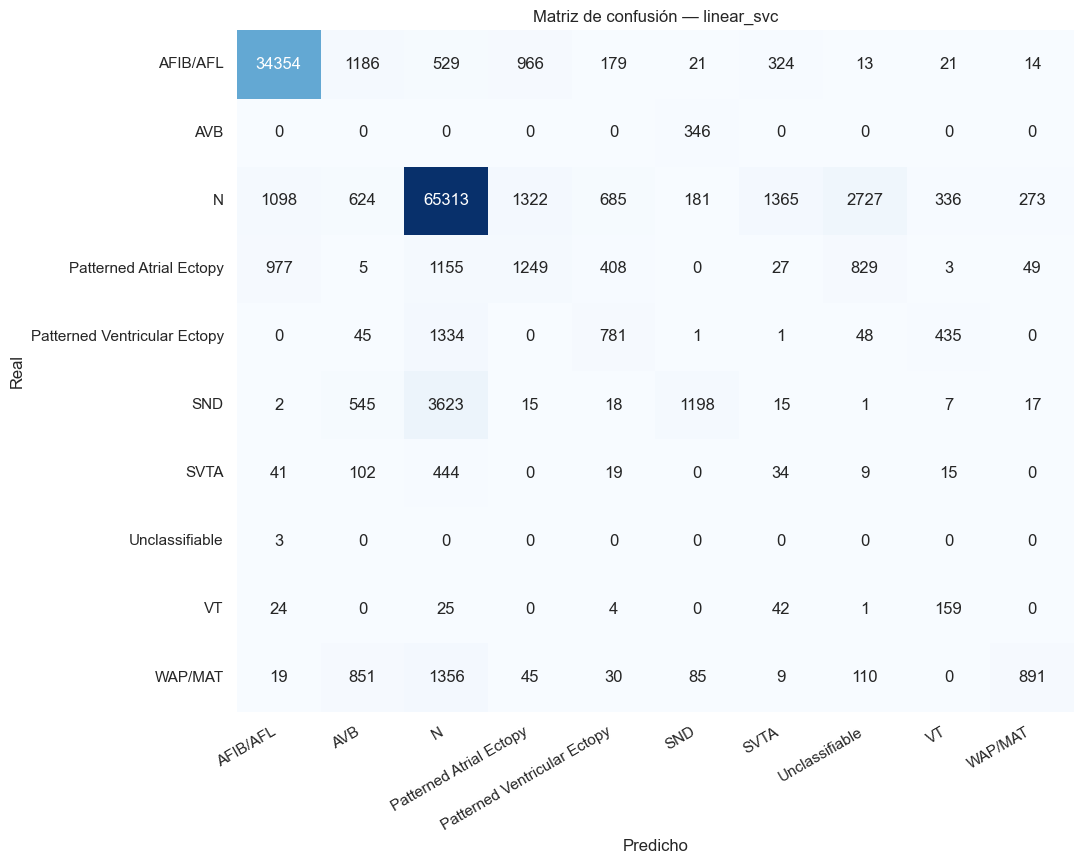

Guardada: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\figures\best_model_confusion_matrix.png


In [13]:
if winner_row is None:
    print("Sin ganador válido; nada que graficar.")
else:
    labels = sorted(
        set(pd.Series(y_test).unique()) | set(pd.Series(y_pred_winner).unique()),
        key=str,
    )
    cm = confusion_matrix(y_test, y_pred_winner, labels=labels)

    fig, ax = plt.subplots(figsize=(1.0 + len(labels), 0.8 + 0.8 * len(labels)))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        cbar=False, ax=ax,
    )
    ax.set_title(f"Matriz de confusión — {winner_name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()

    config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    cm_path = config.FIGURES_DIR / "best_model_confusion_matrix.png"
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardada: {cm_path}")

## 13. Importancia de variables del mejor modelo

- Si el modelo tiene `feature_importances_` (Random Forest, XGBoost, Decision Tree): se usa directamente.
- Si tiene `coef_` (LinearSVC, LogReg): se calcula la norma L2 de los coeficientes por feature.
- Si no tiene ninguno: se informa claramente.

Fuente de importancia : |coef_| (norma L2 por feature)

Top 10 features — linear_svc:
      feature  importance
  case_rr_std   11.569155
case_rr_rmssd   11.297480
          std    5.177698
          var    4.547444
       energy    4.472212
      rr_prev    2.823098
     abs_mean    2.734078
         mean    2.367602
     kurtosis    2.226488
rr_mean_local    1.820967

Guardado: C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\tables\best_model_feature_importance.csv


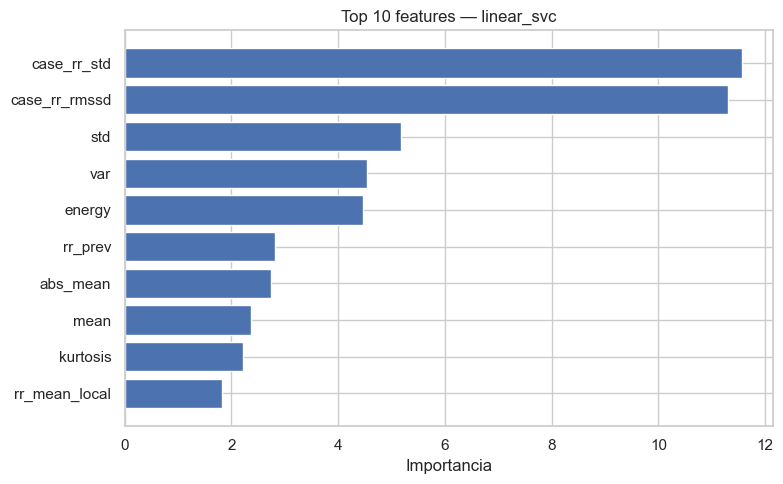

In [14]:
if winner_row is None:
    print("Sin ganador; no hay importancia de variables.")

else:
    best_estimator = winner_row["_best_estimator"]
    clf = best_estimator.named_steps["clf"]

    importances = None
    imp_label   = None

    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        imp_label   = "feature_importances_"
    elif hasattr(clf, "coef_"):
        coef = np.asarray(clf.coef_)
        importances = np.linalg.norm(coef, axis=0) if coef.ndim > 1 else np.abs(coef.ravel())
        imp_label   = "|coef_| (norma L2 por feature)"

    if importances is not None:
        imp_df = (
            pd.DataFrame({"feature": feature_cols, "importance": importances})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        print(f"Fuente de importancia : {imp_label}")
        print(f"\nTop 10 features — {winner_name}:")
        print(imp_df.head(10).to_string(index=False))

        config.TABLES_DIR.mkdir(parents=True, exist_ok=True)
        imp_path = config.TABLES_DIR / "best_model_feature_importance.csv"
        imp_df.head(10).to_csv(imp_path, index=False)
        print(f"\nGuardado: {imp_path}")

        top10 = imp_df.head(10)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.barh(top10["feature"][::-1], top10["importance"][::-1])
        ax.set_xlabel("Importancia")
        ax.set_title(f"Top 10 features — {winner_name}")
        plt.tight_layout()
        plt.show()

    else:
        print(
            f"El modelo {winner_name} no expone importancia de variables directa.\n"
            "(No tiene `feature_importances_` ni `coef_`)"
        )

## 14. Guardado de reportes, modelos y metadatos

Archivos generados:
- `reports/tables/model_comparison.csv` — tabla comparativa de todos los modelos.
- `reports/tables/best_model_classification_report.csv` — reporte por clase del ganador.
- `reports/tables/best_model_feature_importance.csv` — top 10 features (si aplica).
- `reports/figures/best_model_confusion_matrix.png` — matriz de confusión visual.
- `models/<name>_best_pipeline.joblib` — pipeline entrenado de cada modelo con `status='ok'`.
- `models/best_model_pipeline.joblib` — pipeline del ganador global (mayor `test_f1_macro`).
- `models/feature_columns.json` — lista exacta de `feature_cols` para reproducibilidad.
- `models/model_artifacts_metadata.json` — metadata completa del entrenamiento (fechas, versiones, hiperparámetros, rutas).

In [15]:
import importlib
import joblib
from datetime import datetime

# ── Directorios ───────────────────────────────────────────────────────────────
config.TABLES_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = config.MODELS_DIR

# ── 14a. CSV de comparación ───────────────────────────────────────────────────
comp_path = config.TABLES_DIR / "model_comparison.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"[OK] {comp_path}")

# ── 14b. Classification report del ganador ────────────────────────────────────
if winner_row is not None:
    rep_dict = classification_report(y_test, y_pred_winner, output_dict=True, zero_division=0)
    rep_df   = pd.DataFrame(rep_dict).T
    rep_path = config.TABLES_DIR / "best_model_classification_report.csv"
    rep_df.to_csv(rep_path)
    print(f"[OK] {rep_path}")
else:
    print("[--] Sin ganador: no se guardó classification_report.")

# ── 14c. Modelos con joblib ───────────────────────────────────────────────────
saved_model_paths = {}
for row in model_rows:
    if row.get("status") != "ok" or row.get("_best_estimator") is None:
        continue
    mname    = row["model"]
    out_path = MODELS_DIR / f"{mname}_best_pipeline.joblib"
    joblib.dump(row["_best_estimator"], out_path)
    saved_model_paths[mname] = str(out_path)
    print(f"[OK] {out_path}")

# Mejor modelo global
best_model_path = None
if winner_row is not None and winner_row.get("_best_estimator") is not None:
    best_model_path = MODELS_DIR / "best_model_pipeline.joblib"
    joblib.dump(winner_row["_best_estimator"], best_model_path)
    print(f"[OK] {best_model_path}  <- ganador global ({winner_name})")

# ── 14d. Feature columns JSON ─────────────────────────────────────────────────
feat_cols_path = MODELS_DIR / "feature_columns.json"
with open(feat_cols_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)
print(f"[OK] {feat_cols_path}")

# ── 14e. Metadata JSON ────────────────────────────────────────────────────────
def _pkg_version(pkg_name: str) -> str:
    try:
        return importlib.import_module(pkg_name).__version__
    except Exception:
        return "unknown"

try:
    import xgboost as _xgb
    _xgb_ver = _xgb.__version__
except ImportError:
    _xgb_ver = "not installed"

_best_hp: dict = {}
for row in model_rows:
    if row.get("status") == "ok":
        try:
            _best_hp[row["model"]] = json.loads(row["best_params"])
        except Exception:
            _best_hp[row["model"]] = row.get("best_params")

metadata = {
    "training_datetime":          datetime.now().isoformat(),
    "fast_mode":                  FAST_MODE,
    "winner_model":               winner_name,
    "primary_metric":             "test_f1_macro",
    "winner_test_f1_macro":       float(winner_row["test_f1_macro"]) if winner_row else None,
    "target":                     config.TARGET_COLUMN,
    "forbidden_columns":          list(config.FORBIDDEN_FEATURE_COLUMNS),
    "feature_cols":               feature_cols,
    "n_features":                 len(feature_cols),
    "train_size_rows":            int(len(train_idx)),
    "test_size_rows":             int(len(test_idx)),
    "n_train_groups":             len(train_groups_set),
    "n_test_groups":              len(test_groups_set),
    "best_hyperparams_per_model": _best_hp,
    "saved_model_paths":          saved_model_paths,
    "best_model_path":            str(best_model_path) if best_model_path else None,
    "library_versions": {
        "sklearn":  _pkg_version("sklearn"),
        "numpy":    _pkg_version("numpy"),
        "pandas":   _pkg_version("pandas"),
        "xgboost":  _xgb_ver,
        "joblib":   _pkg_version("joblib"),
    },
}
meta_path = MODELS_DIR / "model_artifacts_metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"[OK] {meta_path}")

# ── Resumen ────────────────────────────────────────────────────────────────────
print("\nResumen de archivos de reporte:")
for label, p in [
    ("Comparacion modelos (CSV)",     comp_path),
    ("Classification report (CSV)",   config.TABLES_DIR / "best_model_classification_report.csv"),
    ("Feature importance (CSV)",      config.TABLES_DIR / "best_model_feature_importance.csv"),
    ("Matriz de confusion (PNG)",     config.FIGURES_DIR / "best_model_confusion_matrix.png"),
    ("Feature columns (JSON)",        feat_cols_path),
    ("Metadata entrenamiento (JSON)", meta_path),
]:
    icon = "OK" if Path(p).exists() else "--"
    print(f"  [{icon}] {label}")

[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\tables\model_comparison.csv
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\tables\best_model_classification_report.csv
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\linear_svc_best_pipeline.joblib
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\decision_tree_best_pipeline.joblib
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\random_forest_best_pipeline.joblib
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\xgboost_best_pipeline.joblib
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\mlp_best_pipeline.joblib
[OK] C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine

## 15. Verificación del modelo guardado

Carga `models/best_model_pipeline.joblib` desde disco y verifica que:
- el número de features coincide con `feature_cols`, y
- puede predecir sobre las primeras 5 muestras de test.

In [16]:
print("=" * 60)
print("VERIFICACION DEL MEJOR MODELO GUARDADO")
print("=" * 60)

if best_model_path is None or not Path(best_model_path).exists():
    print("No hay modelo guardado que verificar.")
else:
    loaded_pipeline = joblib.load(best_model_path)

    # Verificar número de features
    n_feat_model = getattr(loaded_pipeline, "n_features_in_", None)
    print(f"Ruta cargada            : {best_model_path}")
    print(f"Features (feature_cols) : {len(feature_cols)}")
    print(f"Features (modelo)       : {n_feat_model}")

    if n_feat_model is not None:
        assert n_feat_model == len(feature_cols), (
            f"MISMATCH de features: modelo={n_feat_model}, feature_cols={len(feature_cols)}"
        )
        print("Coincidencia de features: OK")

    # Predicciones en las primeras 5 muestras de test
    sample_X = X_test[:5]
    sample_y = y_test[:5]
    preds     = loaded_pipeline.predict(sample_X)

    print(f"\nPredicciones para las primeras 5 muestras de test:")
    print(f"  {'#':>2}  {'Predicho':32s}  {'Real':32s}  Match")
    print("  " + "-" * 76)
    for i, (p, r) in enumerate(zip(preds, sample_y)):
        mark = "OK" if p == r else "NO"
        print(f"  {i:>2}  {str(p):32s}  {str(r):32s}  {mark}")

VERIFICACION DEL MEJOR MODELO GUARDADO
Ruta cargada            : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\best_model_pipeline.joblib
Features (feature_cols) : 26
Features (modelo)       : 26
Coincidencia de features: OK

Predicciones para las primeras 5 muestras de test:
   #  Predicho                          Real                              Match
  ----------------------------------------------------------------------------
   0  N                                 N                                 OK
   1  N                                 N                                 OK
   2  N                                 N                                 OK
   3  N                                 N                                 OK
   4  N                                 N                                 OK


## 15. Notas metodológicas

- El notebook usa `features_baseline.parquet` generado en `04_windowing_and_feature_engineering.ipynb`.
  Si en el futuro se generan parquets con distintas duraciones de ventana, la estructura del notebook
  sigue siendo válida — solo cambiar el archivo de entrada en la sección 4.
- El split y CV están anclados a `case_id`. Ningún paciente aparece en train y test simultáneamente.
- `beat_type` está bloqueado por `assert_no_forbidden_features`; no puede entrar como predictor.
- **Para resultados finales**: poner `FAST_MODE = False` en la sección 2 y re-ejecutar el notebook entero.
- Los reportes finales se guardan en `reports/tables/` y `reports/figures/`.
- Antes de interpretar las métricas, revisar la sección 6: si una clase aparece en muy pocos
  `case_id` únicos, puede que quede fuera de train o test en algún split, haciendo su
  recall/F1 no interpretable como métrica estable.

In [17]:
print("=" * 70)
print("RESUMEN FINAL DE LA CORRIDA")
print("=" * 70)
_mode_label = "RAPIDA DE PRUEBA" if FAST_MODE else "COMPLETA"
print(f"FAST_MODE   : {FAST_MODE}  ({_mode_label}  N_ITER={N_ITER})")
print()

ok_models   = [r["model"] for r in model_rows if r.get("status") == "ok"]
fail_models = [r["model"] for r in model_rows if r.get("status") != "ok"]

print(f"Modelos entrenados OK : {ok_models}")
print(f"Modelos fallidos      : {fail_models}")

if fail_models:
    print("\nDetalle de fallos:")
    for r in model_rows:
        if r.get("status") != "ok":
            print(f"  [{r['model']}] {r.get('error_message', '')[:130]}")

print()
if winner_row:
    print(f"Modelo ganador  : {winner_name}")
    print(f"  test_f1_macro : {winner_row['test_f1_macro']:.4f}")
    print(f"  Ruta guardada : {best_model_path}")
else:
    print("Modelo ganador  : NINGUNO (todos fallaron)")

print()
print("Rutas de artefactos:")
_artifacts = [
    ("CSV comparacion modelos",      config.TABLES_DIR / "model_comparison.csv"),
    ("Classification report (CSV)",  config.TABLES_DIR / "best_model_classification_report.csv"),
    ("Matriz de confusion (PNG)",    config.FIGURES_DIR / "best_model_confusion_matrix.png"),
    ("Feature columns (JSON)",       MODELS_DIR / "feature_columns.json"),
    ("Metadata entrenamiento (JSON)",MODELS_DIR / "model_artifacts_metadata.json"),
]
for mname, mpath in saved_model_paths.items():
    _artifacts.append((f"Modelo {mname}", Path(mpath)))
if best_model_path:
    _artifacts.append(("Mejor modelo global", Path(best_model_path)))

for label, path in _artifacts:
    icon = "OK" if Path(path).exists() else "--"
    print(f"  [{icon}] {label:42s}: {path}")

if FAST_MODE:
    print()
    print("NOTA: Para resultados finales cambia FAST_MODE=False y re-ejecuta el notebook.")
    print("      Tambien puedes re-correr solo un modelo: FORCE_RERUN_MODELS = ['xgboost']")

RESUMEN FINAL DE LA CORRIDA
FAST_MODE   : True  (RAPIDA DE PRUEBA  N_ITER=5)

Modelos entrenados OK : ['linear_svc', 'decision_tree', 'random_forest', 'xgboost', 'mlp']
Modelos fallidos      : []

Modelo ganador  : linear_svc
  test_f1_macro : 0.3439
  Ruta guardada : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\models\best_model_pipeline.joblib

Rutas de artefactos:
  [OK] CSV comparacion modelos                   : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\tables\model_comparison.csv
  [OK] Classification report (CSV)               : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\tables\best_model_classification_report.csv
  [OK] Matriz de confusion (PNG)                 : C:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\reports\figures\best_model_confusion_matrix.png
  [OK] Feature columns (JSON)     